In [1]:
from google.colab import drive, userdata

drive.mount('/content/drive')

GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")

%cd /content
!git clone https://{GITHUB_TOKEN}@github.com/Bassey-data/Auto-insurance-claim-frequency.git

%cd /content/Auto-insurance-claim-frequency
!git config user.email "basseysamuel404@gmail.com"
!git config user.name "Bassey-data"
!git remote set-url origin https://{GITHUB_TOKEN}@github.com/Bassey-data/Auto-insurance-claim-frequency.git
!git checkout feature/gbm-modeling

print("Setup complete")

Mounted at /content/drive
/content
Cloning into 'Auto-insurance-claim-frequency'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 71 (delta 31), reused 41 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 473.04 KiB | 4.55 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/Auto-insurance-claim-frequency
Branch 'feature/gbm-modeling' set up to track remote branch 'feature/gbm-modeling' from 'origin'.
Switched to a new branch 'feature/gbm-modeling'
Setup complete


In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_poisson_deviance
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("Imports OK")

Imports OK


In [3]:
def parse_arff(path):
    columns = []
    data_start = None

    with open(path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.lower().startswith("@attribute"):
            parts = stripped.split(maxsplit=2)
            columns.append(parts[1])
        elif stripped.lower().startswith("@data"):
            data_start = i + 1
            break

    data_lines = [l.strip() for l in lines[data_start:] if l.strip()]

    rows = []
    for line in data_lines:
        values = [v.strip().strip("'").strip('"') for v in line.split(",")]
        rows.append(values)

    return pd.DataFrame(rows, columns=columns)

In [5]:
def prepare_data():
    from sklearn.model_selection import train_test_split

    parquet_path = "data/processed/freMTPL2freq.parquet"
    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
    else:
        df = parse_arff("/content/drive/MyDrive/ACQsci.arff")
        df_converted = df.apply(pd.to_numeric, errors="ignore")
        for col in df_converted.select_dtypes(include="object").columns:
            df_converted[col] = df_converted[col].astype("category")
        df = df_converted
        os.makedirs("data/processed", exist_ok=True)
        df.to_parquet(parquet_path, index=False)

    # Apply caps
    df["VehAge"] = df["VehAge"].clip(upper=20)
    df["Exposure"] = df["Exposure"].clip(upper=1)
    df["ClaimNb"] = df["ClaimNb"].clip(upper=4)

    # Area ordinal encoding
    area_order = sorted(df["Area"].cat.categories)
    area_map = {cat: i for i, cat in enumerate(area_order)}
    df["Area_ord"] = df["Area"].map(area_map).astype(int)

    # Train/test split
    nominal_cols = ["VehBrand", "VehGas", "Region"]
    df["had_claim"] = (df["ClaimNb"] > 0).astype(int)
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["had_claim"])
    train_df = train_df.drop(columns="had_claim")
    test_df = test_df.drop(columns="had_claim")

    # GBM feature sets - keep categoricals native, no one-hot encoding
    train_gbm = train_df.drop(columns="Area").copy()
    test_gbm = test_df.drop(columns="Area").copy()
    for col in nominal_cols:
        train_gbm[col] = train_gbm[col].astype("category")
        test_gbm[col] = test_gbm[col].astype("category")

    # Save
    os.makedirs("data/processed", exist_ok=True)
    train_gbm.to_parquet("data/processed/train_gbm.parquet", index=False)
    test_gbm.to_parquet("data/processed/test_gbm.parquet", index=False)

    print("Data ready")
    return train_gbm, test_gbm


# Check if files exist, regenerate if not
if not os.path.exists("data/processed/train_gbm.parquet"):
    train, test = prepare_data()
else:
    train = pd.read_parquet("data/processed/train_gbm.parquet")
    test = pd.read_parquet("data/processed/test_gbm.parquet")
    print("Loaded from parquet")

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

Data ready
Train: (542410, 12)
Test:  (135603, 12)


In [7]:
# Feature columns - everything except ID, target and offset
feature_cols = [c for c in train.columns if c not in ("IDpol", "ClaimNb", "Exposure")]
categorical_cols = [c for c in feature_cols if train[c].dtype.name == "category"]

X_train = train[feature_cols]
y_train = train["ClaimNb"]
exposure_train = train["Exposure"]
offset_train = np.log(exposure_train)

X_test = test[feature_cols]
y_test = test["ClaimNb"]
exposure_test = test["Exposure"]
offset_test = np.log(exposure_test)

print(f"Features: {feature_cols}")
print(f"Categorical features: {categorical_cols}")

Features: ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region', 'Area_ord']
Categorical features: ['VehBrand', 'VehGas', 'Region']


In [8]:
# Create LightGBM datasets
# init_score=offset sets the starting point for boosting to account for exposure
train_set = lgb.Dataset(
    X_train,
    label=y_train,
    init_score=offset_train,
    categorical_feature=categorical_cols,
    free_raw_data=False
)

valid_set = lgb.Dataset(
    X_test,
    label=y_test,
    init_score=offset_test,
    categorical_feature=categorical_cols,
    reference=train_set,
    free_raw_data=False
)

print("Datasets created")

Datasets created


In [9]:
params = {
    "objective": "poisson",
    "metric": "poisson",
    "learning_rate": 0.03,
    "num_leaves": 15,
    "min_data_in_leaf": 500,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l2": 1.0,
    "verbose": -1,
    "seed": 42,
}

gbm_model = lgb.train(
    params,
    train_set,
    num_boost_round=2000,
    valid_sets=[train_set, valid_set],
    valid_names=["train", "valid"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ],
)

print(f"\nBest iteration: {gbm_model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[100]	train's poisson: 0.256684	valid's poisson: 0.255888
[200]	train's poisson: 0.207791	valid's poisson: 0.207447
[300]	train's poisson: 0.201786	valid's poisson: 0.201784
[400]	train's poisson: 0.20066	valid's poisson: 0.200906
[500]	train's poisson: 0.200123	valid's poisson: 0.200575
[600]	train's poisson: 0.199747	valid's poisson: 0.200396
[700]	train's poisson: 0.19943	valid's poisson: 0.200281
[800]	train's poisson: 0.199157	valid's poisson: 0.20018
[900]	train's poisson: 0.198905	valid's poisson: 0.20011
[1000]	train's poisson: 0.198663	valid's poisson: 0.200059
[1100]	train's poisson: 0.198432	valid's poisson: 0.199991
[1200]	train's poisson: 0.198216	valid's poisson: 0.199958
[1300]	train's poisson: 0.197999	valid's poisson: 0.199907
[1400]	train's poisson: 0.197796	valid's poisson: 0.199879
[1500]	train's poisson: 0.197593	valid's poisson: 0.199856
[1600]	train's poisson: 0.197398	valid's poisson: 0.199827
[1700]	t

In [10]:
# raw_score=True gives us the model output before the Poisson link function
raw_train_pred = gbm_model.predict(X_train, num_iteration=gbm_model.best_iteration, raw_score=True)
raw_test_pred = gbm_model.predict(X_test, num_iteration=gbm_model.best_iteration, raw_score=True)

# Add offset back and exponentiate to get expected claim counts
train_pred = np.exp(raw_train_pred + offset_train.values)
test_pred = np.exp(raw_test_pred + offset_test.values)

print("Sample predictions (test):", test_pred[:5])
print("Sample actuals (test):    ", y_test.values[:5])

Sample predictions (test): [0.24704234 0.03031708 0.00247963 0.09067901 0.00129906]
Sample actuals (test):     [0 0 0 0 0]


Compute Poisson deviance and load GLM results for comparison

In [12]:
# Compute Poisson deviance
train_deviance = mean_poisson_deviance(y_train, train_pred)
test_deviance = mean_poisson_deviance(y_test, test_pred)

# Load GLM results for comparison
with open("reports/glm_results.json") as f:
    glm_results = json.load(f)

naive_deviance = glm_results["naive_deviance"]

print(f"Naive baseline test deviance: {naive_deviance:.4f}")
print(f"Poisson GLM test deviance:    {glm_results['test_deviance']:.4f}")
print(f"LightGBM train deviance:      {train_deviance:.4f}")
print(f"LightGBM test deviance:       {test_deviance:.4f}")
print()
improvement_vs_naive = (1 - test_deviance / naive_deviance) * 100
improvement_vs_glm = (1 - test_deviance / glm_results["test_deviance"]) * 100
print(f"LightGBM improves on naive baseline by {improvement_vs_naive:.1f}%")
print(f"LightGBM improves on GLM by            {improvement_vs_glm:.1f}%")

Naive baseline test deviance: 0.3294
Poisson GLM test deviance:    0.3191
LightGBM train deviance:      0.2953
LightGBM test deviance:       0.3016

LightGBM improves on naive baseline by 8.4%
LightGBM improves on GLM by            5.5%


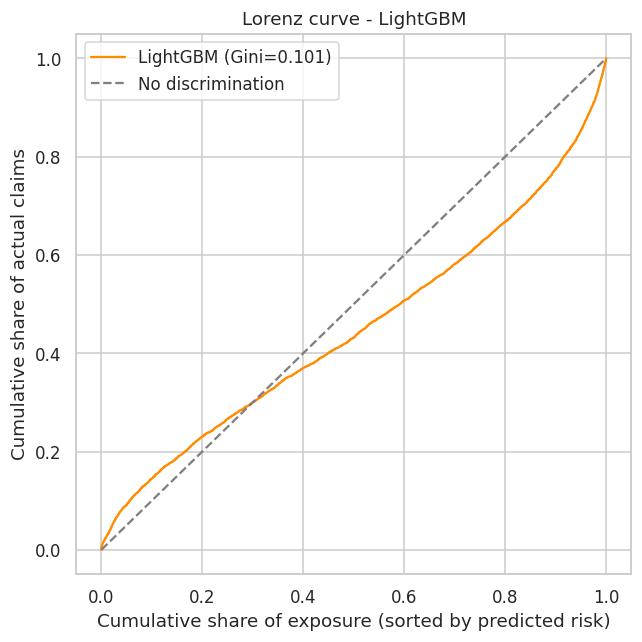

LightGBM Gini: 0.1010
GLM Gini:      -0.0473


In [13]:
def lorenz_curve(y_true, y_pred, exposure):
    order = np.argsort(y_pred)
    y_true_sorted = np.array(y_true)[order]
    exposure_sorted = np.array(exposure)[order]
    cum_exposure = np.cumsum(exposure_sorted) / exposure_sorted.sum()
    cum_claims = np.cumsum(y_true_sorted) / y_true_sorted.sum()
    return cum_exposure, cum_claims

def gini_index(cum_exposure, cum_claims):
    return 1 - 2 * np.trapezoid(cum_claims, cum_exposure)

cum_exp_gbm, cum_claims_gbm = lorenz_curve(y_test, test_pred, exposure_test)
gini_gbm = gini_index(cum_exp_gbm, cum_claims_gbm)

plt.figure(figsize=(6, 6))
plt.plot(cum_exp_gbm, cum_claims_gbm, label=f"LightGBM (Gini={gini_gbm:.3f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="No discrimination")
plt.xlabel("Cumulative share of exposure (sorted by predicted risk)")
plt.ylabel("Cumulative share of actual claims")
plt.title("Lorenz curve - LightGBM")
plt.legend()
plt.tight_layout()
plt.show()

print(f"LightGBM Gini: {gini_gbm:.4f}")
print(f"GLM Gini:      {glm_results['gini']:.4f}")

Feature importance by gain to see how much each feature contributed to reducing loss


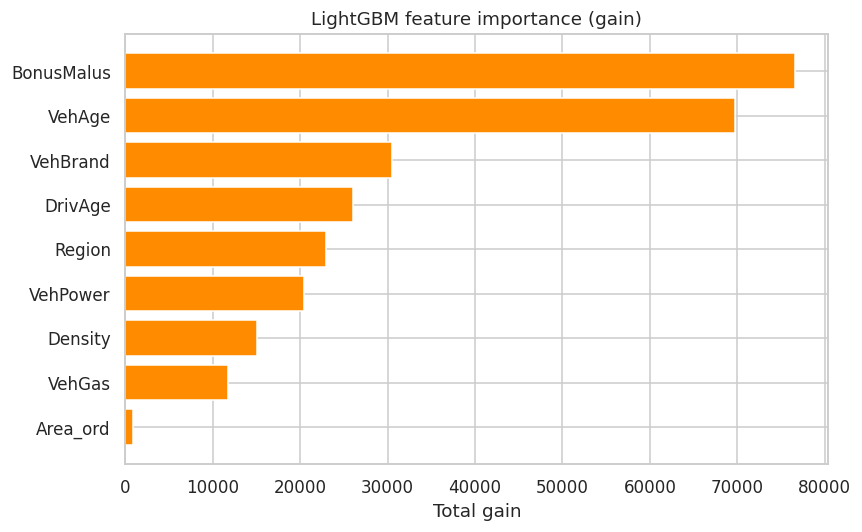

      feature    importance
3  BonusMalus  76580.822943
1      VehAge  69764.903651
4    VehBrand  30473.673863
2     DrivAge  26011.002959
7      Region  22975.294218
0    VehPower  20448.384297
6     Density  15030.474232
5      VehGas  11716.202236
8    Area_ord    869.187660


In [14]:
 importance_df = pd.DataFrame({
    "feature": gbm_model.feature_name(),
    "importance": gbm_model.feature_importance(importance_type="gain")
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="darkorange")
plt.title("LightGBM feature importance (gain)")
plt.xlabel("Total gain")
plt.tight_layout()
plt.show()

print(importance_df)